# Customer Churn Prediction
## Logistic Regression vs. Random Forest — End-to-End ML Pipeline

**Topics covered:**
- Kaggle data download via `kagglehub`
- Exploratory Data Analysis (EDA)
- Data Cleaning & Feature Engineering
- Class Imbalance — SMOTE & class weights
- Logistic Regression — coefficients, odds ratios, interpretation
- Random Forest Classifier — feature importance, tuning
- Cutoff probability selection (business-driven thresholding)
- ROC-AUC, Precision-Recall curves
- Confusion matrix deep-dive
- Model comparison & business recommendations

---
> **Why churn?** Acquiring a new customer costs 5–25× more than retaining one. A 5% improvement in retention can increase profits by 25–95% (Bain & Company). This makes churn prediction one of the highest-ROI ML applications in business.

## 0. Install & Import Libraries

In [48]:
# Uncomment if running for the first time
# !pip install kagglehub pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

In [49]:
import kagglehub
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
print('All libraries imported successfully.')

All libraries imported successfully.


---
## 1. Download Data from Kaggle

In [50]:
# Download latest version
path = kagglehub.dataset_download("miadul/customer-churn-prediction-business-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\shrip\.cache\kagglehub\datasets\miadul\customer-churn-prediction-business-dataset\versions\1


In [51]:
# List downloaded files
files = os.listdir(path)
print("Files:", files)

# Load the first CSV found
csv_files = [f for f in files if f.endswith('.csv')]
df_raw = pd.read_csv(os.path.join(path, csv_files[0]))
print(f"\nLoaded: {csv_files[0]}  |  Shape: {df_raw.shape}")
df_raw.head()

Files: ['customer_churn_business_dataset.csv']

Loaded: customer_churn_business_dataset.csv  |  Shape: (10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


---
## 2. Exploratory Data Analysis (EDA)

> **Goal:** Understand the data structure, distributions, missing values, and the target variable balance before touching a model.

In [52]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Rows: {df_raw.shape[0]:,}   |   Columns: {df_raw.shape[1]}")
print("\nColumn dtypes:")
print(df_raw.dtypes)
print("\nMemory usage:", df_raw.memory_usage(deep=True).sum() / 1024, "KB")

DATASET OVERVIEW
Rows: 10,000   |   Columns: 32

Column dtypes:
customer_id                   str
gender                        str
age                         int64
country                       str
city                          str
customer_segment              str
tenure_months               int64
signup_channel                str
contract_type                 str
monthly_logins              int64
weekly_active_days          int64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method                str
payment_failures            int64
discount_applied              str
price_increase_last_3m        str
support_tickets             int64
avg_resolution_time       float64
complaint_type                str
csat_score                float64
escalations                 int64
email_open_rate           float64
marketing_click_ra

In [53]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  str    
 1   gender                  10000 non-null  str    
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  str    
 4   city                    10000 non-null  str    
 5   customer_segment        10000 non-null  str    
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  str    
 8   contract_type           10000 non-null  str    
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null  int64  
 1

In [54]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000,10000,CUST_00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,45.9061,16.420416,18.0,32.0,46.0,60.0,74.0
country,10000,7,Bangladesh,1494,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,10000,7,London,1518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,10000,3,Individual,5984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,10000.0,NaN,NaN,NaN,30.1557,17.099517,1.0,16.0,30.0,45.0,59.0
signup_channel,10000,3,Web,5036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contract_type,10000,3,Monthly,4967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_logins,10000.0,NaN,NaN,NaN,19.672,9.838003,0.0,13.0,20.0,26.0,54.0


### 2.1 Target Variable Distribution

> **Key concept — Class Imbalance:**  
> In most real churn datasets, churners are a minority (5–30%). A naive model that predicts "No Churn" for everyone achieves high accuracy but is **useless**. This is why we never use plain accuracy as the primary metric for imbalanced problems.

Candidate target columns: ['churn']
Using target column: 'churn'

Class distribution:
       Count  Percentage
churn                   
0       8979       89.79
1       1021       10.21


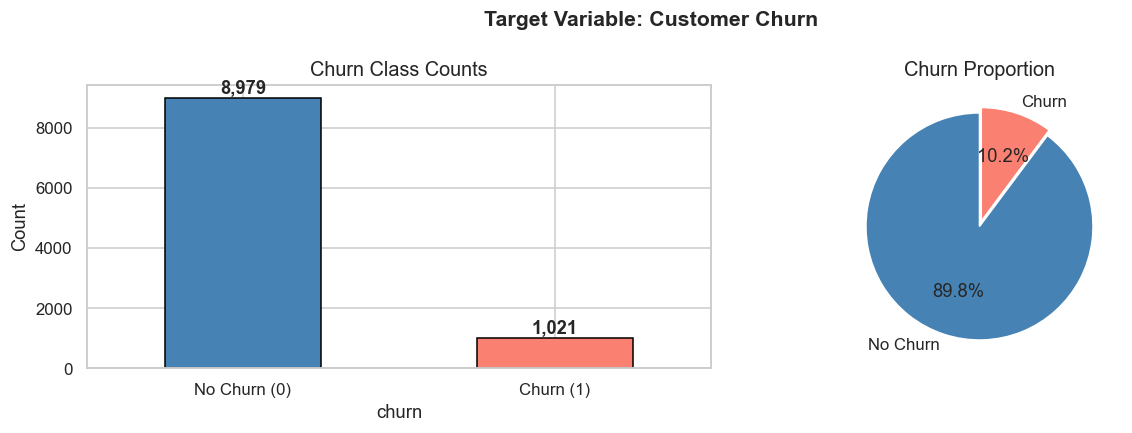


Imbalance ratio (Majority:Minority) = 8.8:1
⚠  Dataset is IMBALANCED. We must handle this before modeling.


In [55]:
# Identify the target column (common names: Churn, churn, Exited, churned)
target_candidates = [c for c in df_raw.columns if 'churn' in c.lower() or 'exit' in c.lower()]
print("Candidate target columns:", target_candidates)

TARGET = target_candidates[0] if target_candidates else df_raw.columns[-1]
print(f"Using target column: '{TARGET}'")

# Standardise to 0/1 if needed
if df_raw[TARGET].dtype == object:
    df_raw[TARGET] = df_raw[TARGET].map({'Yes': 1, 'No': 0, 'True': 1, 'False': 0})
    df_raw[TARGET] = df_raw[TARGET].astype(int)

churn_counts = df_raw[TARGET].value_counts()
churn_pct = df_raw[TARGET].value_counts(normalize=True) * 100

print("\nClass distribution:")
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Churn Class Counts', fontsize=13)
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

axes[1].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=['steelblue', 'salmon'], startangle=90, explode=(0, 0.05))
axes[1].set_title('Churn Proportion', fontsize=13)
plt.suptitle('Target Variable: Customer Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

imbalance_ratio = churn_counts[0] / churn_counts[1]
print(f"\nImbalance ratio (Majority:Minority) = {imbalance_ratio:.1f}:1")
if imbalance_ratio > 3:
    print("⚠  Dataset is IMBALANCED. We must handle this before modeling.")
else:
    print("✓  Dataset is relatively balanced.")

### 2.2 Missing Values

                Missing Count  Missing %
complaint_type           2045      20.45


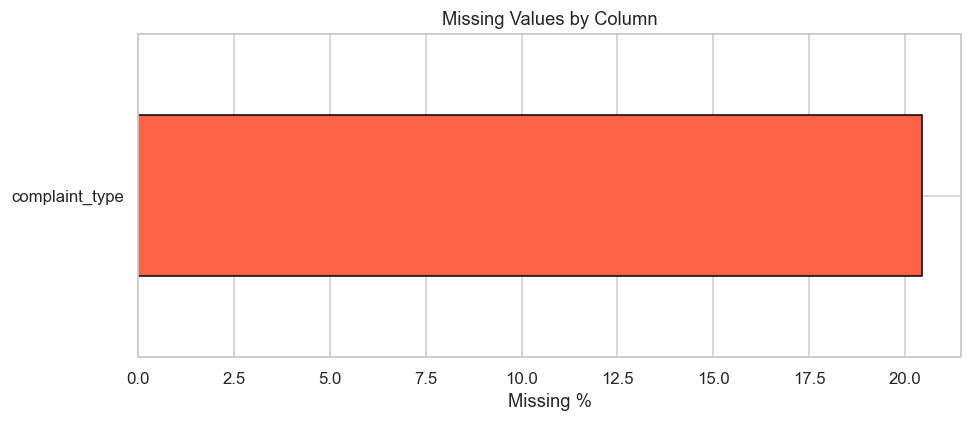

In [56]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print("No missing values found.")
else:
    print(missing_df)
    ax = missing_df['Missing %'].plot(kind='barh', figsize=(9, 4), color='tomato', edgecolor='black')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

### 2.3 Numeric Feature Distributions

Numeric features (19): ['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count']


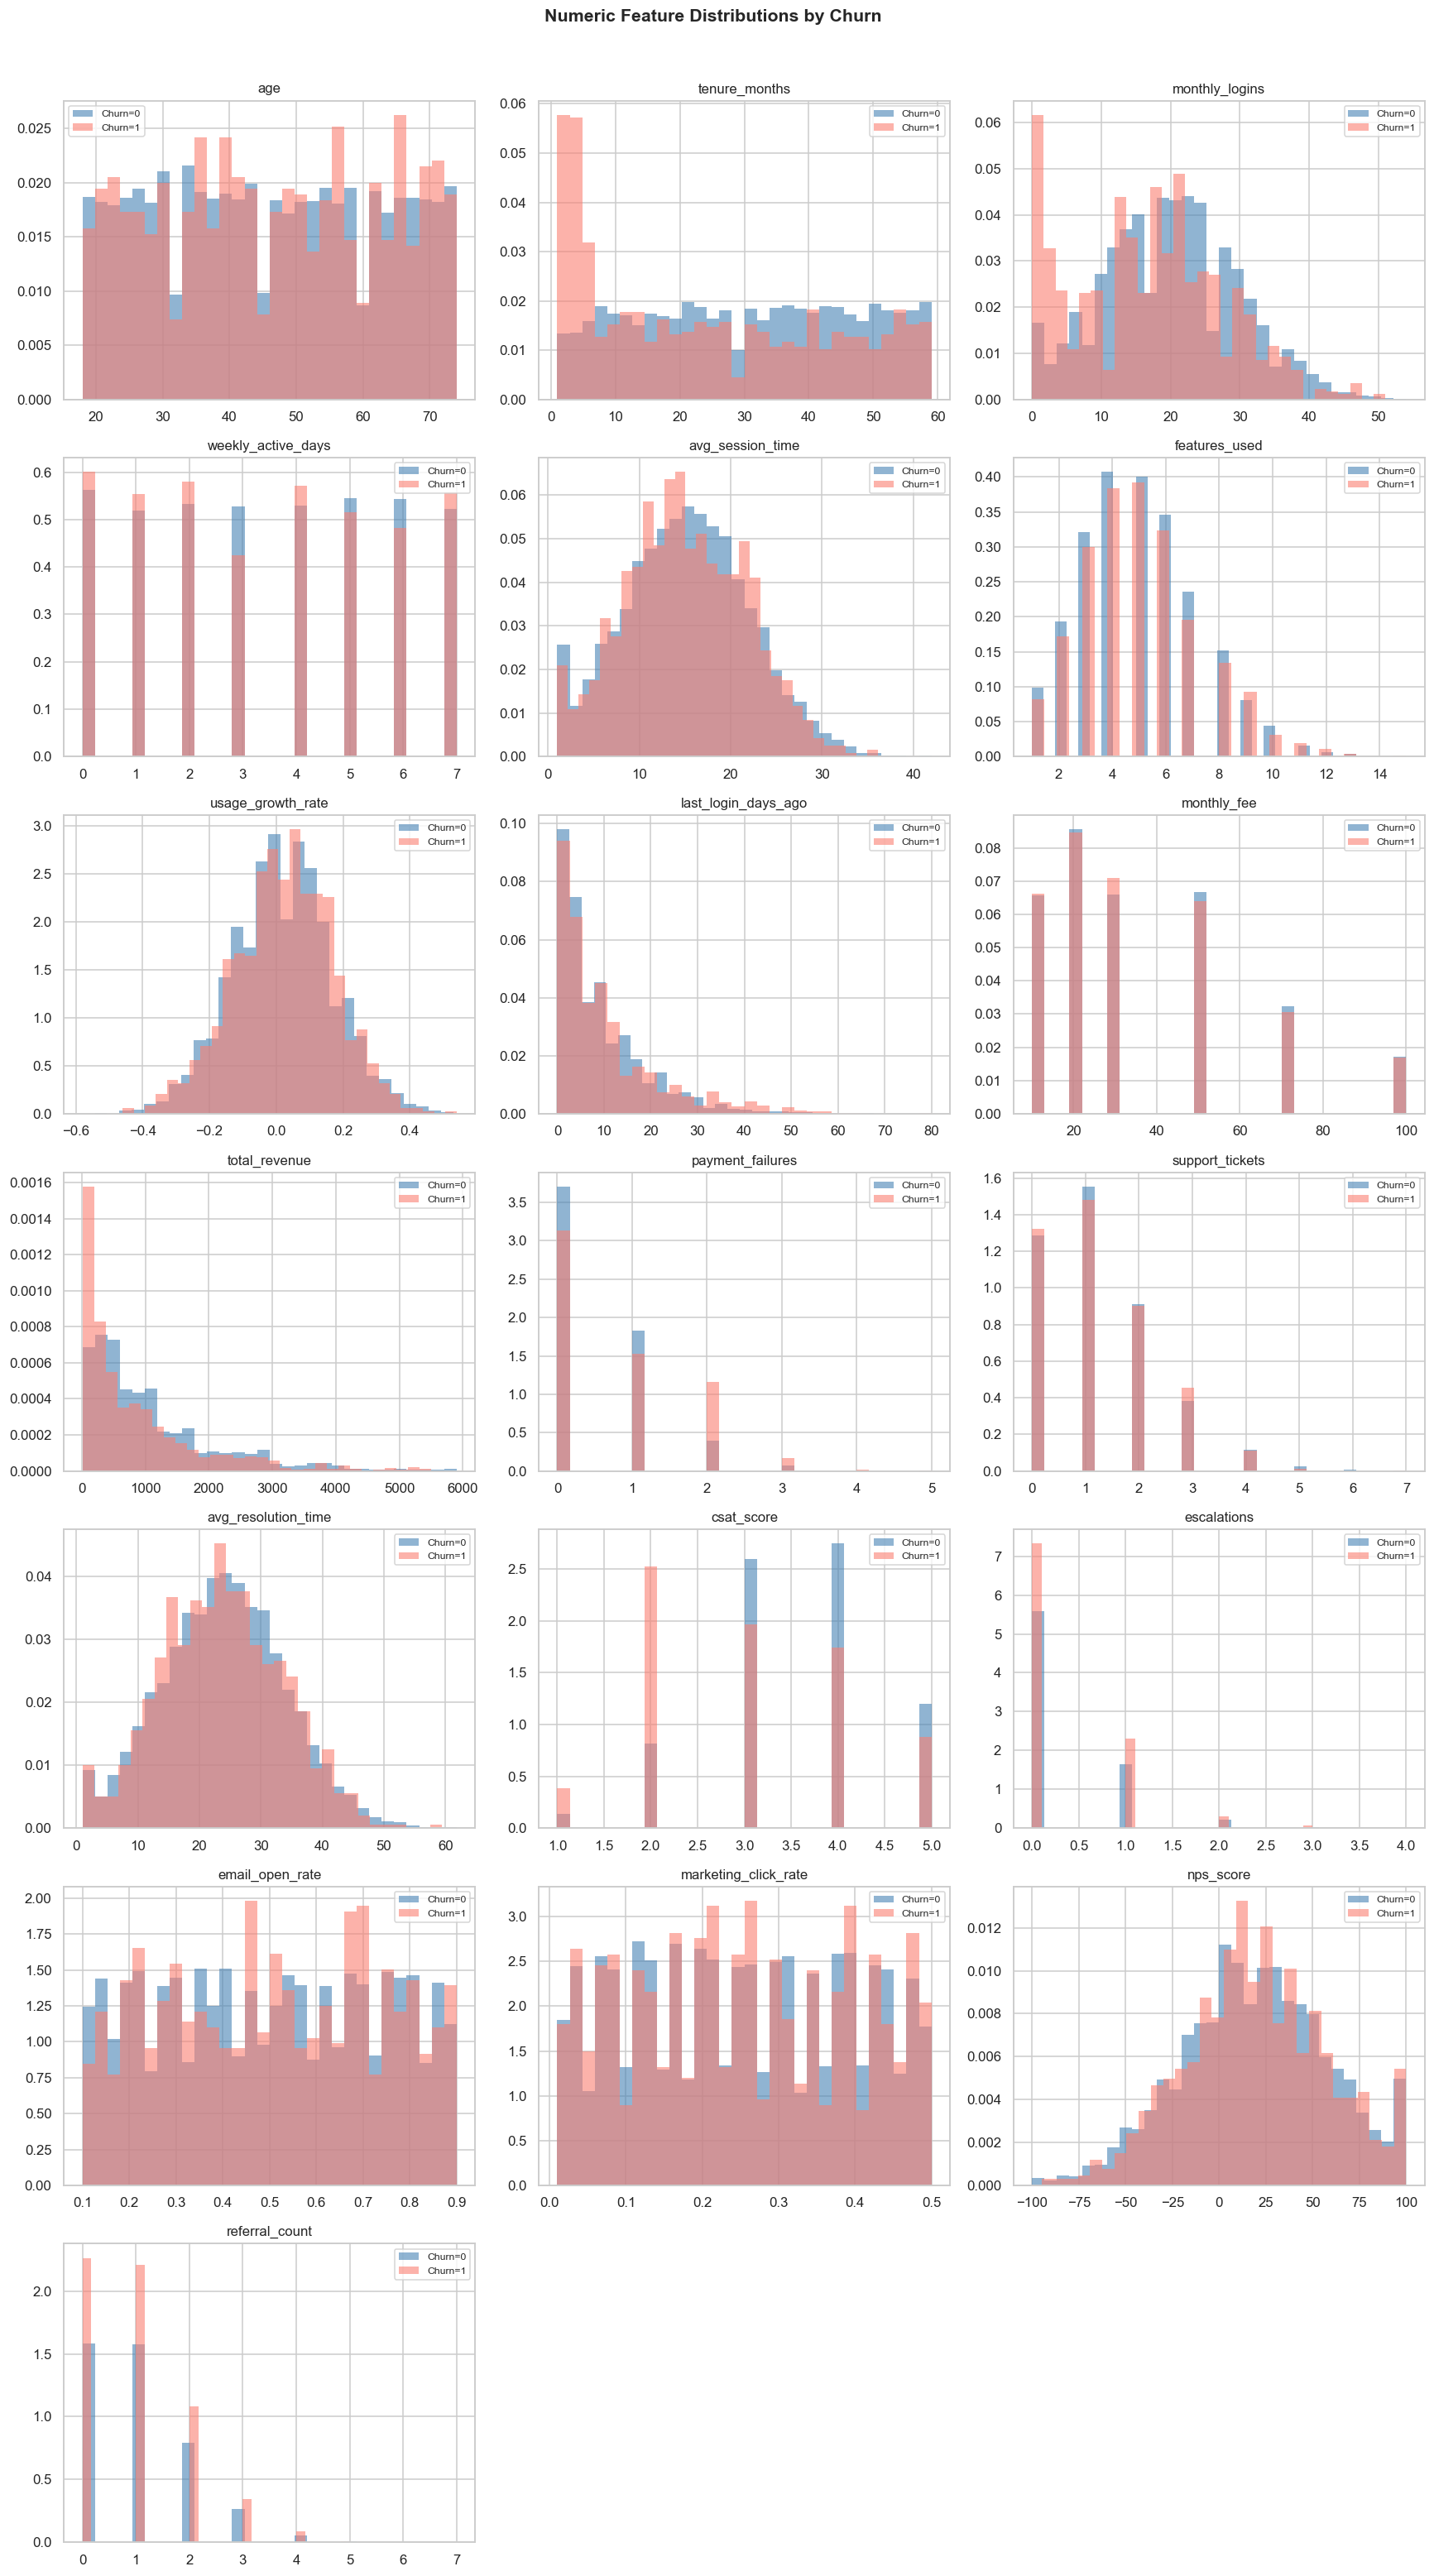

In [57]:
num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]
print(f"Numeric features ({len(num_cols)}): {num_cols}")

n = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip([0, 1], ['steelblue', 'salmon']):
        axes[i].hist(df_raw[df_raw[TARGET] == label][col].dropna(),
                     bins=30, alpha=0.6, color=color,
                     label=f'Churn={label}', density=True, edgecolor='none')
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions by Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.4 Categorical Feature Distributions

Categorical features (11): ['gender', 'country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']


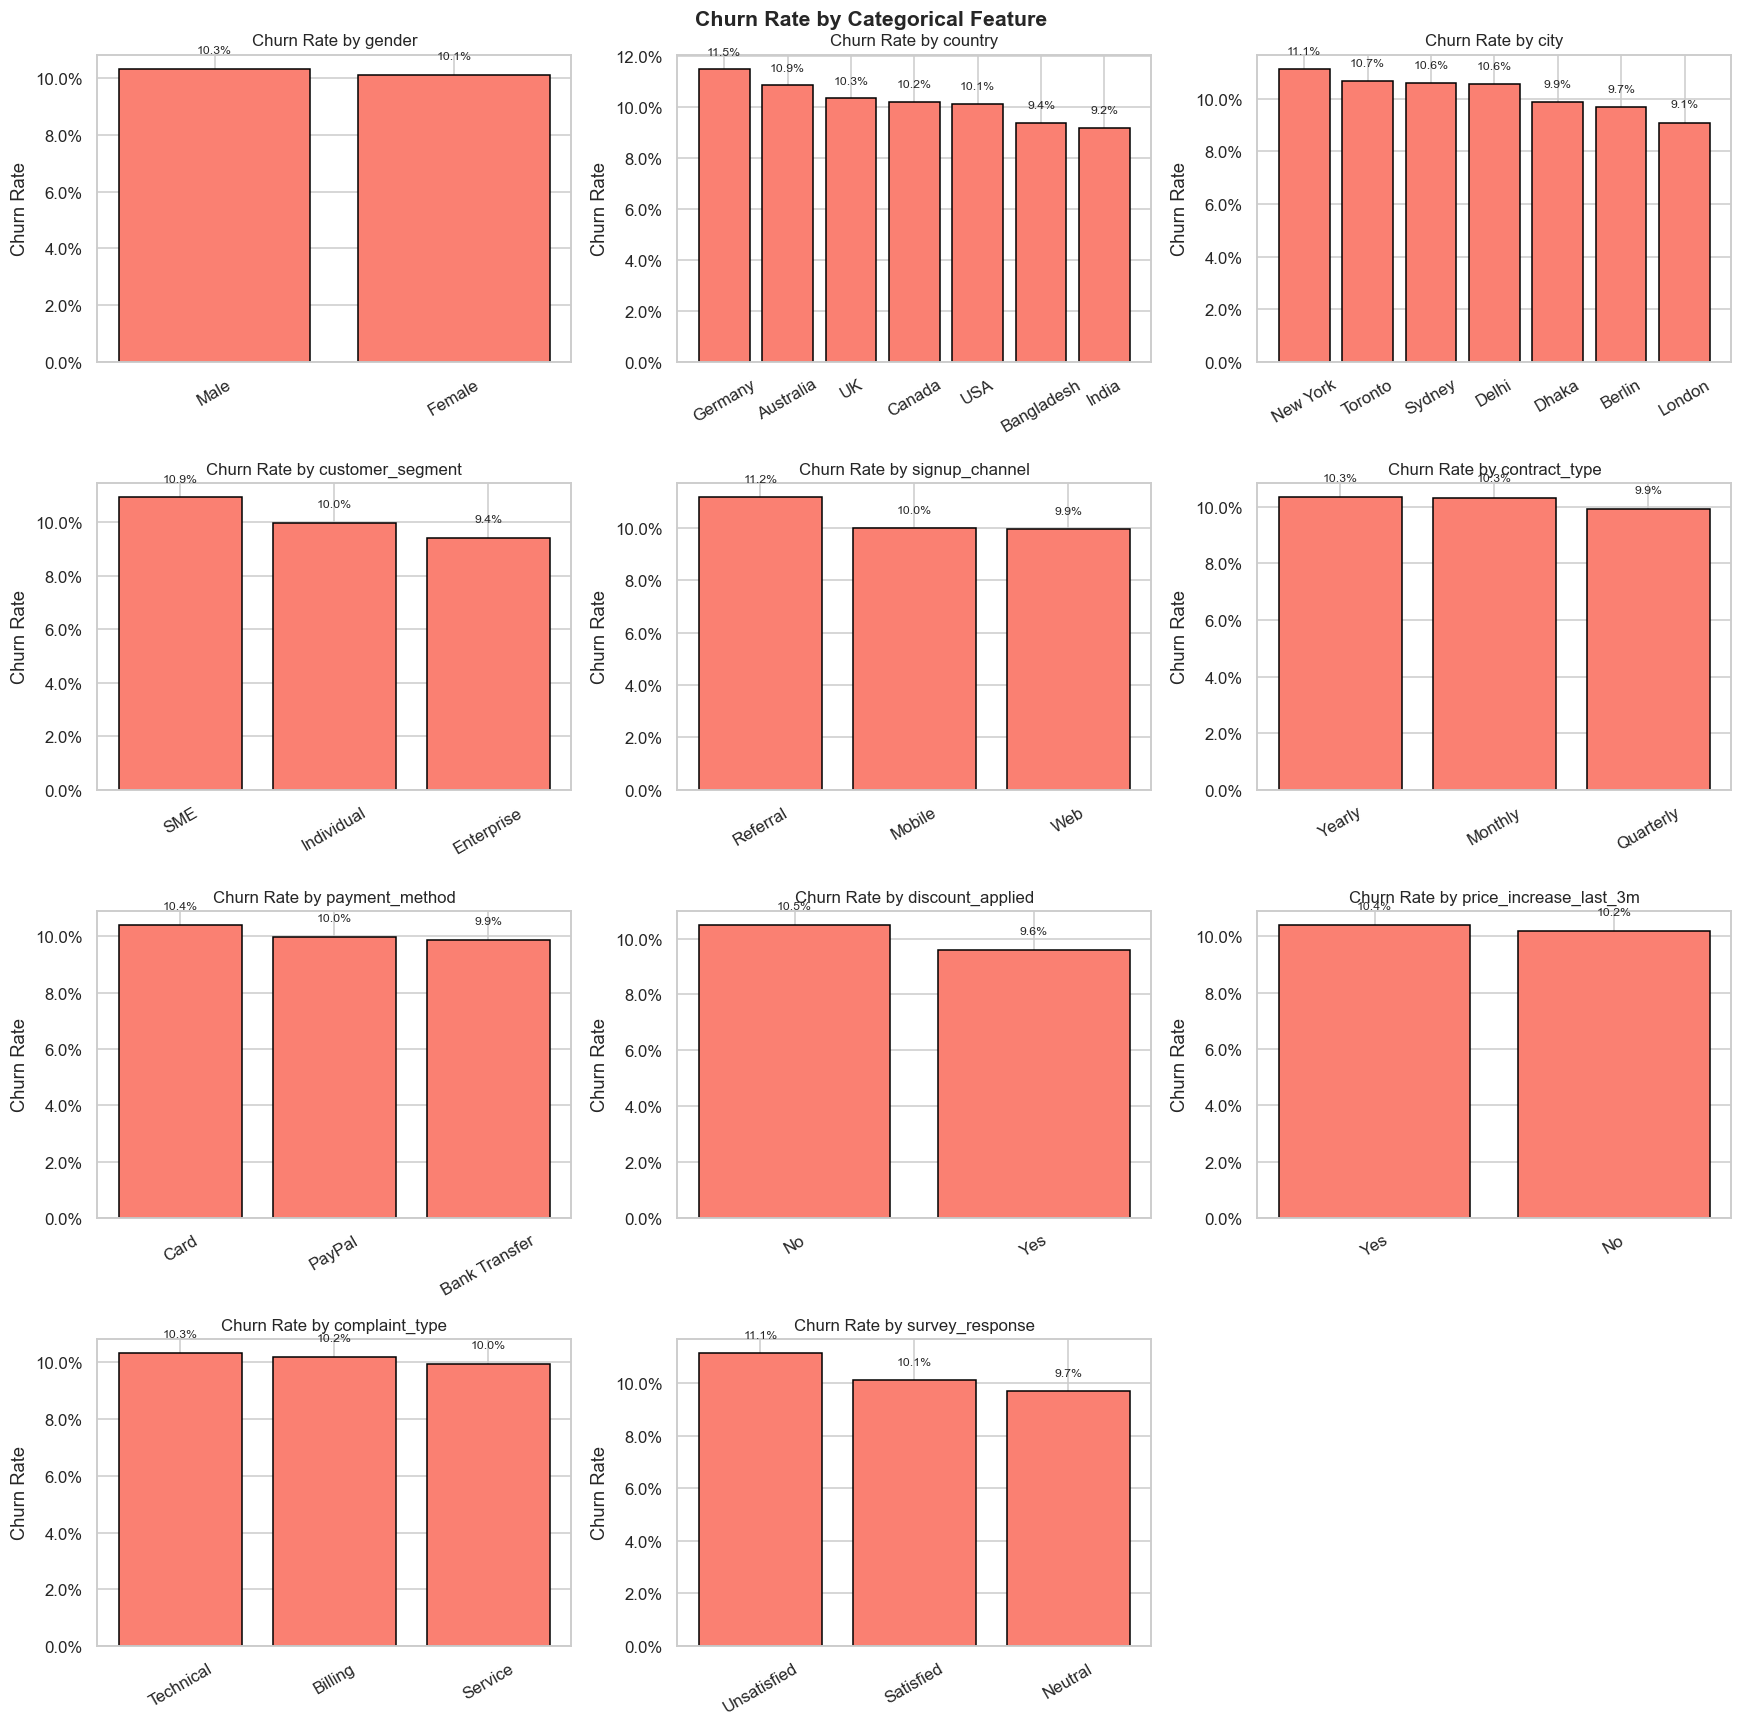

In [58]:
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
# Exclude ID-like columns (high cardinality)
cat_cols = [c for c in cat_cols if df_raw[c].nunique() < 20]
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

if cat_cols:
    n = len(cat_cols)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
    axes = np.array(axes).flatten()

    for i, col in enumerate(cat_cols):
        churn_rate = df_raw.groupby(col)[TARGET].mean().sort_values(ascending=False)
        bars = axes[i].bar(churn_rate.index, churn_rate.values, color='salmon', edgecolor='black')
        axes[i].set_title(f'Churn Rate by {col}', fontsize=11)
        axes[i].set_ylabel('Churn Rate')
        axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        axes[i].tick_params(axis='x', rotation=30)
        for bar in bars:
            axes[i].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 0.005,
                         f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 2.5 Correlation Heatmap

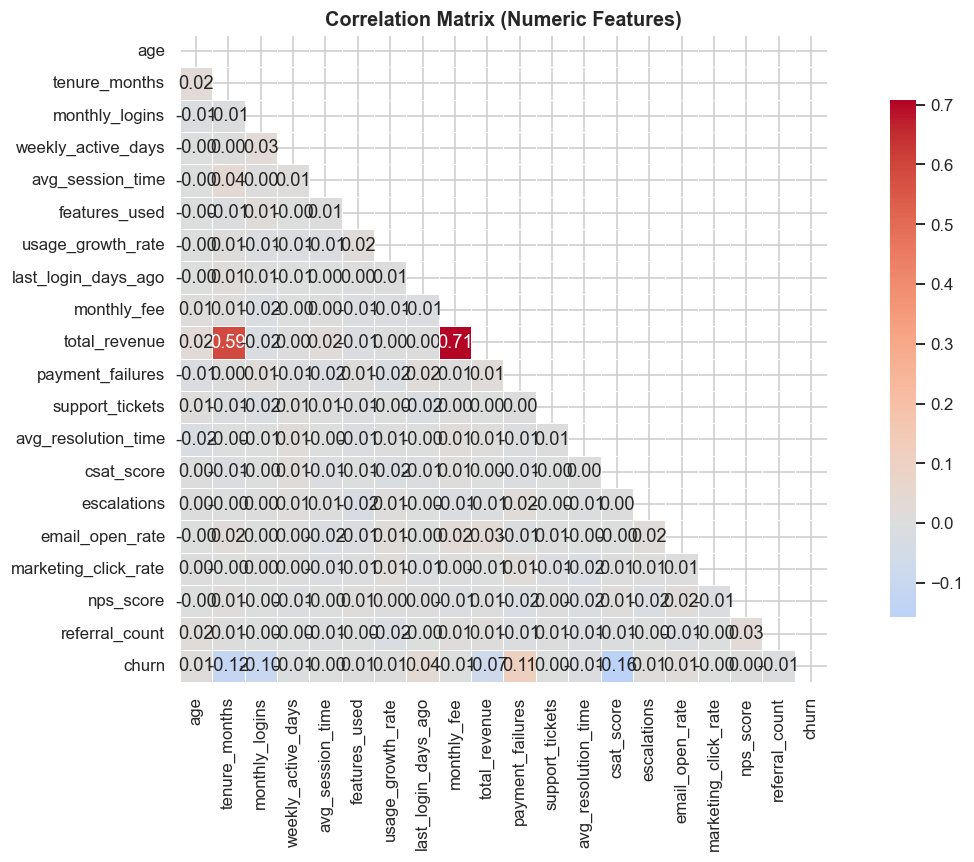


Top correlations with Churn:
csat_score            -0.157924
tenure_months         -0.117014
payment_failures       0.112494
monthly_logins        -0.098339
total_revenue         -0.070120
last_login_days_ago    0.037250
email_open_rate        0.011506
age                    0.010155
escalations            0.009561
avg_resolution_time   -0.009172


In [59]:
corr_cols = num_cols + [TARGET]
corr_matrix = df_raw[corr_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Highlight top correlations with target
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print("\nTop correlations with Churn:")
print(target_corr.head(10).to_string())

---
## 3. Data Cleaning & Feature Engineering

In [60]:
df = df_raw.copy()

# ── 3.1  Drop ID / high-cardinality columns ──
id_cols = [c for c in df.columns
           if 'id' in c.lower() or 'name' in c.lower() or df[c].nunique() == len(df)]
print("Dropping ID/high-cardinality columns:", id_cols)
df.drop(columns=id_cols, inplace=True, errors='ignore')

print(f"Shape after drop: {df.shape}")

Dropping ID/high-cardinality columns: ['customer_id']
Shape after drop: (10000, 31)


In [61]:
# ── 3.2  Handle Missing Values ──
for col in df.columns:
    miss_pct = df[col].isnull().mean()
    if miss_pct == 0:
        continue
    if miss_pct > 0.5:
        print(f"Dropping '{col}' — {miss_pct:.0%} missing")
        df.drop(columns=[col], inplace=True)
    elif not pd.api.types.is_numeric_dtype(df[col]):
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"Filled '{col}' (categorical) with mode")
    else:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Filled '{col}' (numeric) with median")

print(f"Missing values remaining: {df.isnull().sum().sum()}")

Filled 'complaint_type' (categorical) with mode
Missing values remaining: 2045


In [62]:
# ── 3.3  Encode Categorical Variables ──
# Binary categoricals → LabelEncoder
# Multi-class categoricals → One-Hot Encoding

str_cols = df.select_dtypes(include=["object", "string"]).columns

binary_cats = [c for c in str_cols if df[c].nunique() == 2]
multi_cats  = [c for c in str_cols if df[c].nunique() > 2]

le = LabelEncoder()
for col in binary_cats:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"Label-encoded: {col}")

if multi_cats:
    df = pd.get_dummies(df, columns=multi_cats, drop_first=True)
    print(f"One-hot encoded: {multi_cats}")

# Ensure booleans become int
bool_cols = df.select_dtypes(bool).columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"Final shape: {df.shape}")
df.head(3)

Label-encoded: gender
Label-encoded: discount_applied
Label-encoded: price_increase_last_3m
One-hot encoded: ['country', 'city', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'complaint_type', 'survey_response']
Final shape: (10000, 47)


,gender,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,...,signup_channel_Referral,signup_channel_Web,contract_type_Quarterly,contract_type_Yearly,payment_method_Card,payment_method_PayPal,complaint_type_Service,complaint_type_Technical,survey_response_Satisfied,survey_response_Unsatisfied
0,1,68,22,26,7,11.762372,5,0.06,7,30,...,0,1,0,0,0,1,1,0,1,0
1,0,57,9,7,5,26.846390,1,-0.28,2,30,...,0,0,0,0,1,0,0,0,0,0
2,1,24,58,19,5,23.380065,6,0.13,23,20,...,0,1,0,1,1,0,1,0,0,0


---
## 4. Data Preparation for Modeling

In [63]:
# ── 4.1  Feature / Target Split ──
# Drop total_revenue: highly correlated with tenure_months (multicollinearity)
# causes sign flip on coefficients despite both having positive correlation with churn
X = df.drop(columns=[TARGET, 'total_revenue'])
y = df[TARGET]

print(f"Features: {X.shape[1]}   |   Samples: {X.shape[0]}")
print(f"Class balance — No Churn: {(y==0).sum():,}  |  Churn: {(y==1).sum():,}")

Features: 45   |   Samples: 10000
Class balance — No Churn: 8,979  |  Churn: 1,021


In [64]:
# ── 4.2  Train / Test Split (Stratified) ──
# Stratified ensures the same class ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")
print(f"Train churn rate: {y_train.mean():.2%}  |  Test churn rate: {y_test.mean():.2%}")

Train size: 7,000  |  Test size: 3,000
Train churn rate: 10.21%  |  Test churn rate: 10.20%


In [65]:
# ── 4.3  Feature Scaling ──
# Required for Logistic Regression (gradient-based, distance-sensitive)
# Not required for Random Forest (tree-based, scale-invariant) — but harmless
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ONLY on train data
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

print("Scaling complete.")
print("  Train mean (post-scale):", np.round(X_train_sc.mean(axis=0)[:5], 4))
print("  Train std  (post-scale):", np.round(X_train_sc.std(axis=0)[:5], 4))

Scaling complete.
  Train mean (post-scale): [ 0. -0. -0. -0. -0.]
  Train std  (post-scale): [1. 1. 1. 1. 1.]


### 4.4 Handling Class Imbalance

> **Interview question: How do you handle imbalanced datasets?**

| Strategy | How | When to Use |
|---|---|---|
| `class_weight='balanced'` | Penalize majority class errors more | Fast, always try first |
| SMOTE (Over-sampling) | Synthesize minority class samples | When you have enough minority data |
| Under-sampling | Remove majority class samples | Very large datasets, losing data is OK |
| Threshold tuning | Move decision boundary | Post-model, business-driven |

> **SMOTE** (Synthetic Minority Over-sampling TEchnique) creates synthetic minority samples by interpolating between real minority-class neighbors in feature space — **not** just duplicating records.

> **Critical rule:** SMOTE must be applied **only on training data**. Never apply it to the test set — that would leak information about test distributions.

In [66]:
# Apply SMOTE only if imbalance ratio > 2
majority_count = (y_train == 0).sum()
minority_count = (y_train == 1).sum()
ratio = majority_count / minority_count

print(f"Train class distribution before SMOTE:")
print(f"  No Churn: {majority_count:,}  |  Churn: {minority_count:,}  |  Ratio: {ratio:.1f}:1")

if ratio > 2:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
    print(f"\nAfter SMOTE:")
    print(f"  No Churn: {(y_train_sm==0).sum():,}  |  Churn: {(y_train_sm==1).sum():,}")
    APPLY_SMOTE = True
else:
    X_train_sm, y_train_sm = X_train_sc, y_train
    print("\nSMOTE not applied — dataset sufficiently balanced.")
    APPLY_SMOTE = False

Train class distribution before SMOTE:
  No Churn: 6,285  |  Churn: 715  |  Ratio: 8.8:1

After SMOTE:
  No Churn: 6,285  |  Churn: 6,285


---
## 5. Logistic Regression

### Theory Recap

Logistic Regression models the **log-odds** (logit) of the positive class:

$$\log\frac{p}{1-p} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n$$

The probability is then recovered via the **sigmoid function**:

$$p = \frac{1}{1 + e^{-(\beta_0 + \beta X)}}$$

**Key interpretations:**
- $\beta_j > 0$: feature $j$ increases the probability of churn
- $e^{\beta_j}$: **odds ratio** — a unit increase in $x_j$ multiplies the odds of churn by $e^{\beta_j}$

**Assumptions:**
1. Linear relationship between log-odds and predictors
2. Observations are independent
3. No severe multicollinearity among features

In [85]:
# ── 5.1  Train Logistic Regression ──
# class_weight='balanced' adjusts loss to account for imbalance automatically
lr = LogisticRegression(
    C=1.0,                    # Regularisation strength (1/lambda); smaller = stronger L2
    class_weight='balanced',  # Handles imbalance within the algorithm
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr.fit(X_train_sm, y_train_sm)
print("Logistic Regression trained.")

# Predictions
y_pred_lr    = lr.predict(X_test_sc)
y_prob_lr    = lr.predict_proba(X_test_sc)[:, 1]  # probability of churn

print(f"\nDefault cutoff (0.65) performance:")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

Logistic Regression trained.

Default cutoff (0.65) performance:
              precision    recall  f1-score   support

    No Churn       0.94      0.69      0.79      2694
       Churn       0.19      0.63      0.29       306

    accuracy                           0.68      3000
   macro avg       0.56      0.66      0.54      3000
weighted avg       0.86      0.68      0.74      3000



### 5.2 Coefficient Interpretation & Odds Ratios

> This is a **key differentiator** of Logistic Regression vs. black-box models — full explainability.

In [83]:
from scipy import stats

feature_names = X.columns.tolist()

# ── P-values via Wald test (Fisher information matrix) ──
p_hat = lr.predict_proba(X_train_sm)[:, 1]
W = p_hat * (1 - p_hat)                                        # per-sample weights
X_design = np.column_stack([np.ones(X_train_sm.shape[0]), X_train_sm])
XtWX = (X_design * W[:, np.newaxis]).T @ X_design              # (p+1)×(p+1) information matrix
try:
    cov_matrix = np.linalg.inv(XtWX)
    se = np.sqrt(np.abs(np.diag(cov_matrix)[1:]))              # std errors, skip intercept
    z_scores = lr.coef_[0] / se
    p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))      # two-tailed Wald p-value
except np.linalg.LinAlgError:
    p_values = np.full(len(lr.coef_[0]), np.nan)

coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': lr.coef_[0],
    'Odds_Ratio':  np.exp(lr.coef_[0]),
    'P_Value':     p_values.round(3),
}).sort_values('Coefficient', ascending=False)

coef_df['Significant'] = coef_df['P_Value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
)

with pd.option_context('display.float_format', '{:.3f}'.format):
    print("Top 10 features INCREASING churn probability:")
    print(coef_df.head(10).to_string(index=False))
    print("\nTop 10 features DECREASING churn probability:")
    print(coef_df.tail(10).to_string(index=False))

print("\nSignificance codes:  *** p<0.001  ** p<0.01  * p<0.05")

Top 10 features INCREASING churn probability:
                    Feature  Coefficient  Odds_Ratio  P_Value Significant
           payment_failures        0.400       1.492    0.000         ***
       customer_segment_SME        0.149       1.160    0.000         ***
customer_segment_Individual        0.126       1.135    0.001          **
  survey_response_Satisfied        0.117       1.124    0.000         ***
        last_login_days_ago        0.107       1.113    0.000         ***
        payment_method_Card        0.079       1.082    0.012           *
                        age        0.072       1.074    0.001          **
survey_response_Unsatisfied        0.055       1.056    0.030           *
                  nps_score        0.026       1.027    0.230            
            country_Germany        0.024       1.024    0.376            

Top 10 features DECREASING churn probability:
                 Feature  Coefficient  Odds_Ratio  P_Value Significant
complaint_type_Technic

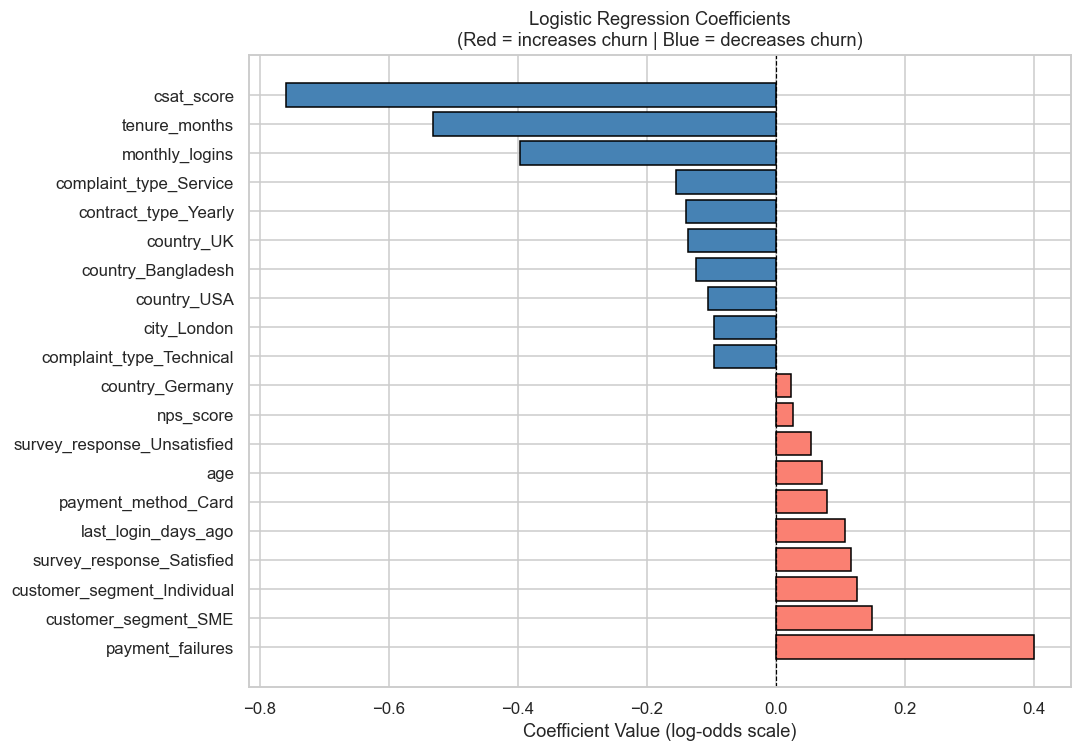


How to interpret:
  - Coefficient = change in log-odds of churn per unit increase in feature
  - Odds Ratio   = exp(coef): how much the ODDS of churn are multiplied
    e.g., Odds Ratio = 1.5 means 50% higher odds of churn
    e.g., Odds Ratio = 0.7 means 30% lower odds of churn



In [69]:
# Visualise top coefficients
top_n = min(20, len(coef_df))
plot_df = pd.concat([coef_df.head(top_n // 2), coef_df.tail(top_n // 2)])

colors = ['salmon' if c > 0 else 'steelblue' for c in plot_df['Coefficient']]
plt.figure(figsize=(10, 7))
plt.barh(plot_df['Feature'], plot_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient Value (log-odds scale)')
plt.title('Logistic Regression Coefficients\n(Red = increases churn | Blue = decreases churn)', fontsize=12)
plt.tight_layout()
plt.show()

print("""
How to interpret:
  - Coefficient = change in log-odds of churn per unit increase in feature
  - Odds Ratio   = exp(coef): how much the ODDS of churn are multiplied
    e.g., Odds Ratio = 1.5 means 50% higher odds of churn
    e.g., Odds Ratio = 0.7 means 30% lower odds of churn
""")

---
## 6. Confusion Matrix — Deep Dive

```
                  Predicted: No Churn    Predicted: Churn
Actual: No Churn     TN (True Neg)         FP (False Pos)   ← Type I Error
Actual: Churn        FN (False Neg)        TP (True Pos)    ← Type II Error
                     ↑ Miss                ↑ Hit
```

| Metric | Formula | Business Meaning |
|---|---|---|
| **Accuracy** | (TP+TN)/N | Misleading for imbalanced data |
| **Precision** | TP/(TP+FP) | Of predicted churners, how many actually churned? |
| **Recall (Sensitivity)** | TP/(TP+FN) | Of actual churners, how many did we catch? |
| **Specificity** | TN/(TN+FP) | Of actual non-churners, how many were correct? |
| **F1 Score** | 2×P×R/(P+R) | Harmonic mean — balanced when FP/FN costs differ |
| **F-beta** | (1+β²)×P×R/(β²×P+R) | β>1 emphasises Recall; β<1 emphasises Precision |

> **Business question:** Which error is more costly — False Positive or False Negative?
> - **FN (missed churner):** Customer leaves uncontacted → lost revenue
> - **FP (wrong alarm):** Discount sent to loyal customer → wasted marketing spend
> - In most churn scenarios: **FN is more costly** → optimise for **Recall**

LOGISTIC REGRESSION — Confusion Matrix (cutoff=0.5)
  Metric          Value
  ──────────────────────
  Accuracy       0.6803
  Precision      0.1851  (of flagged churners, how many are real)
  Recall         0.6275  (of real churners, how many we caught)
  F1             0.2859
  TN/FP/FN/TP  1849/845/114/192


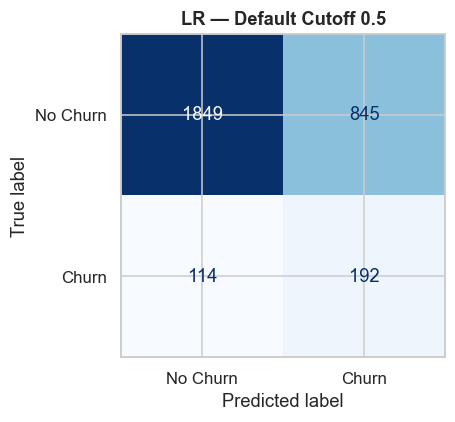

In [70]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix', ax=None):
    cm = confusion_matrix(y_true, y_pred)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    acc       = (tp + tn) / cm.sum()

    print(f"  {'Metric':<12} {'Value':>8}")
    print(f"  {'─'*22}")
    print(f"  {'Accuracy':<12} {acc:>8.4f}")
    print(f"  {'Precision':<12} {precision:>8.4f}  (of flagged churners, how many are real)")
    print(f"  {'Recall':<12} {recall:>8.4f}  (of real churners, how many we caught)")
    print(f"  {'F1':<12} {f1:>8.4f}")
    print(f"  {'TN/FP/FN/TP':<12} {tn}/{fp}/{fn}/{tp}")
    return cm

print("=" * 50)
print("LOGISTIC REGRESSION — Confusion Matrix (cutoff=0.5)")
print("=" * 50)
cm_lr = plot_confusion_matrix(y_test, y_pred_lr, 'LR — Default Cutoff 0.5')
plt.tight_layout()
plt.show()

---
## 7. ROC Curve & AUC — The Full Picture

### What is the ROC Curve?
- **ROC** = Receiver Operating Characteristic
- Plots **True Positive Rate (Recall)** vs. **False Positive Rate** at every possible classification threshold
- **AUC** (Area Under Curve): probability that the model ranks a random positive sample higher than a random negative
  - AUC = 1.0 → perfect model
  - AUC = 0.5 → random guessing (diagonal line)
  - AUC = 0.0 → perfectly wrong model

### When to use Precision-Recall instead of ROC?
> When the **negative class is dominant** (strong imbalance), ROC can be overly optimistic because the large TN pool keeps FPR low. Use the **Precision-Recall curve** in these cases — it focuses only on the positive (minority) class.

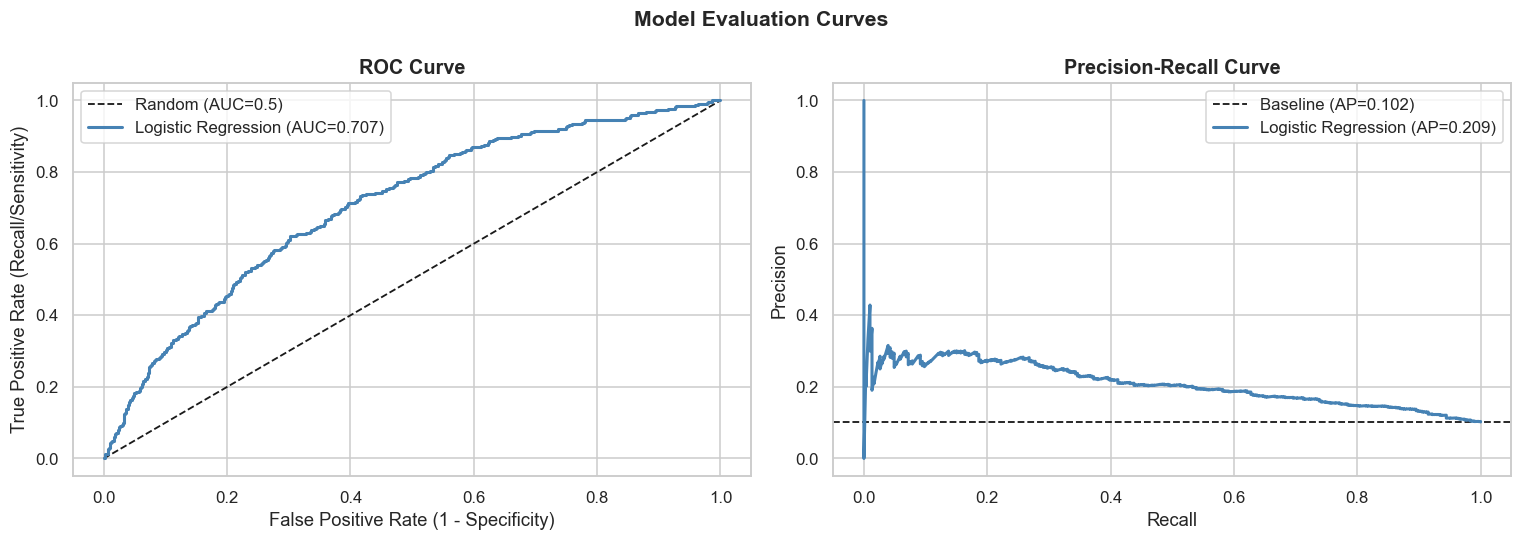


Logistic Regression: ROC-AUC = 0.7074  |  Average Precision = 0.2087


In [71]:
def plot_roc_pr(y_true, y_prob, label, color, ax_roc, ax_pr):
    # ROC
    fpr, tpr, thresholds_roc = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax_roc.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.3f})')

    # Precision-Recall
    precision, recall, thresholds_pr = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    ax_pr.plot(recall, precision, color=color, lw=2, label=f'{label} (AP={ap:.3f})')

    return auc, ap

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 5))

# Diagonal (random classifier)
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC=0.5)')
ax_roc.set_xlabel('False Positive Rate (1 - Specificity)')
ax_roc.set_ylabel('True Positive Rate (Recall/Sensitivity)')
ax_roc.set_title('ROC Curve', fontsize=13, fontweight='bold')

baseline_precision = y_test.mean()
ax_pr.axhline(baseline_precision, color='k', linestyle='--', lw=1.2,
              label=f'Baseline (AP={baseline_precision:.3f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')

auc_lr, ap_lr = plot_roc_pr(y_test, y_prob_lr, 'Logistic Regression', 'steelblue', ax_roc, ax_pr)

ax_roc.legend()
ax_pr.legend()
plt.suptitle('Model Evaluation Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nLogistic Regression: ROC-AUC = {auc_lr:.4f}  |  Average Precision = {ap_lr:.4f}")

---
## 8. Choosing the Optimal Cutoff Probability

### Why 0.5 is rarely the right threshold

The default cutoff of 0.5 assumes **equal cost** for FP and FN. In business, costs are asymmetric:

| Threshold ↓ | Recall ↑ | Precision ↓ | Use when... |
|---|---|---|---|
| Lower (e.g., 0.3) | More churners caught | More false alarms | Missing churners is very costly |
| Higher (e.g., 0.7) | Fewer churners caught | Higher precision | Marketing budget is tight |

### Methods to choose cutoff:
1. **Youden's J statistic:** maximize `TPR - FPR` → best for balanced cost
2. **F1-maximising threshold:** best when you care equally about P and R  
3. **Business cost matrix:** explicitly model revenue loss vs. intervention cost
4. **Recall target:** set minimum acceptable recall (e.g., ≥ 80%) then maximise precision

In [72]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob_lr)
precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_prob_lr)

# ── Method 1: Youden's J ──
youden_j = tpr - fpr
best_idx_j = np.argmax(youden_j)
best_thresh_j = thresholds_roc[best_idx_j]

# ── Method 2: F1-maximising ──
f1_scores = []
thresholds_range = np.linspace(0.01, 0.99, 200)
for t in thresholds_range:
    pred = (y_prob_lr >= t).astype(int)
    f1_scores.append(f1_score(y_test, pred, zero_division=0))

best_thresh_f1 = thresholds_range[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

# ── Method 3: Recall target (≥80%) ──
recall_target = 0.80
results_recall = []
for t in thresholds_range:
    pred = (y_prob_lr >= t).astype(int)
    rec  = recall_score(y_test, pred, zero_division=0)
    prec = precision_score(y_test, pred, zero_division=0)
    results_recall.append((t, rec, prec))
df_thresh = pd.DataFrame(results_recall, columns=['threshold', 'recall', 'precision'])
filtered = df_thresh[df_thresh['recall'] >= recall_target]
best_thresh_recall = filtered.sort_values('precision', ascending=False).iloc[0]['threshold'] if len(filtered) > 0 else best_thresh_f1

print(f"Optimal thresholds:")
print(f"  Youden's J:        {best_thresh_j:.3f}  (TPR={tpr[best_idx_j]:.3f}, FPR={fpr[best_idx_j]:.3f})")
print(f"  F1-maximising:     {best_thresh_f1:.3f}  (F1={best_f1:.3f})")
print(f"  Recall≥{recall_target} target: {best_thresh_recall:.3f}")

Optimal thresholds:
  Youden's J:        0.509  (TPR=0.621, FPR=0.303)
  F1-maximising:     0.576  (F1=0.294)
  Recall≥0.8 target: 0.350


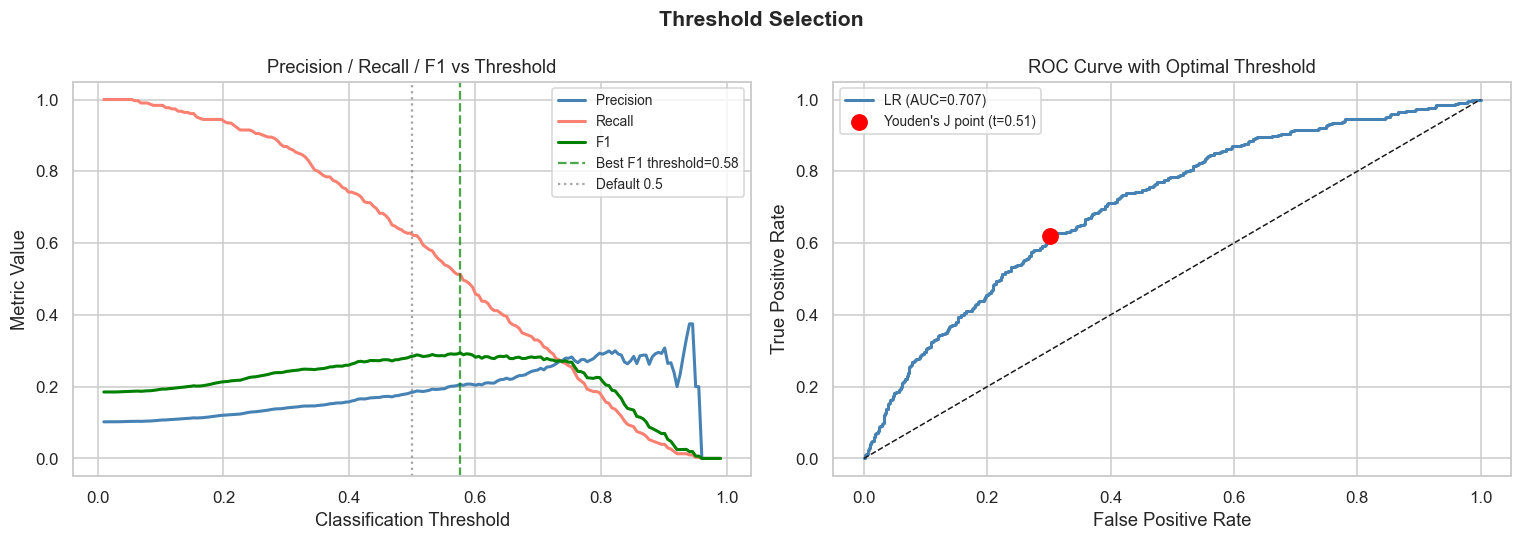

In [73]:
# Visualise threshold vs metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 / Precision / Recall vs threshold
precision_t = [precision_score(y_test, (y_prob_lr >= t).astype(int), zero_division=0) for t in thresholds_range]
recall_t    = [recall_score(y_test, (y_prob_lr >= t).astype(int), zero_division=0) for t in thresholds_range]

axes[0].plot(thresholds_range, precision_t, color='steelblue', lw=2, label='Precision')
axes[0].plot(thresholds_range, recall_t,    color='salmon',    lw=2, label='Recall')
axes[0].plot(thresholds_range, f1_scores,   color='green',     lw=2, label='F1')
axes[0].axvline(best_thresh_f1, color='green', linestyle='--', alpha=0.7,
                label=f'Best F1 threshold={best_thresh_f1:.2f}')
axes[0].axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Default 0.5')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Metric Value')
axes[0].set_title('Precision / Recall / F1 vs Threshold', fontsize=12)
axes[0].legend(fontsize=9)

# ROC with Youden point highlighted
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'LR (AUC={auc_lr:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter(fpr[best_idx_j], tpr[best_idx_j], color='red', s=100, zorder=5,
                label=f"Youden's J point (t={best_thresh_j:.2f})")
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve with Optimal Threshold', fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle('Threshold Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== Logistic Regression: Default threshold (0.5) ===
  Metric          Value
  ──────────────────────
  Accuracy       0.6803
  Precision      0.1851  (of flagged churners, how many are real)
  Recall         0.6275  (of real churners, how many we caught)
  F1             0.2859
  TN/FP/FN/TP  1849/845/114/192

=== Logistic Regression: Optimal threshold (0.58) ===
  Metric          Value
  ──────────────────────
  Accuracy       0.7490
  Precision      0.2063  (of flagged churners, how many are real)
  Recall         0.5131  (of real churners, how many we caught)
  F1             0.2943
  TN/FP/FN/TP  2090/604/149/157


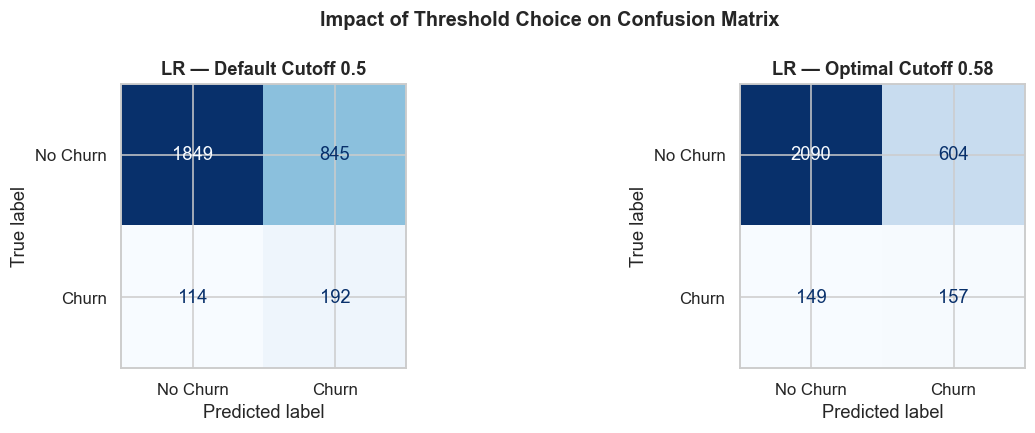

In [74]:
# Apply F1-optimal threshold and compare
y_pred_lr_opt = (y_prob_lr >= best_thresh_f1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

print("=== Logistic Regression: Default threshold (0.5) ===")
cm_default = plot_confusion_matrix(y_test, y_pred_lr, 'LR — Default Cutoff 0.5', ax=axes[0])

print(f"\n=== Logistic Regression: Optimal threshold ({best_thresh_f1:.2f}) ===")
cm_optimal = plot_confusion_matrix(y_test, y_pred_lr_opt, f'LR — Optimal Cutoff {best_thresh_f1:.2f}', ax=axes[1])

plt.suptitle('Impact of Threshold Choice on Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Random Forest Classifier

In [75]:
# ── 9.1  Train Random Forest ──
# RF handles imbalance via class_weight. SMOTE data also works.
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# RF can use raw (unscaled) features — trees are scale-invariant
rf.fit(X_train_sm, y_train_sm)
print("Random Forest trained.")

y_pred_rf = rf.predict(X_test_sc)
y_prob_rf = rf.predict_proba(X_test_sc)[:, 1]

print(f"\nDefault cutoff (0.5) performance:")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

Random Forest trained.

Default cutoff (0.5) performance:
              precision    recall  f1-score   support

    No Churn       0.90      0.96      0.93      2694
       Churn       0.23      0.11      0.15       306

    accuracy                           0.87      3000
   macro avg       0.57      0.53      0.54      3000
weighted avg       0.84      0.87      0.85      3000



### 9.2 Feature Importance

> **Types of feature importance in Random Forest:**
> - **Gini importance (MDI):** Average reduction in impurity from splits on that feature. Fast but can overestimate high-cardinality features.
> - **Permutation importance:** Measures performance drop when a feature is randomly shuffled. More reliable but slower.

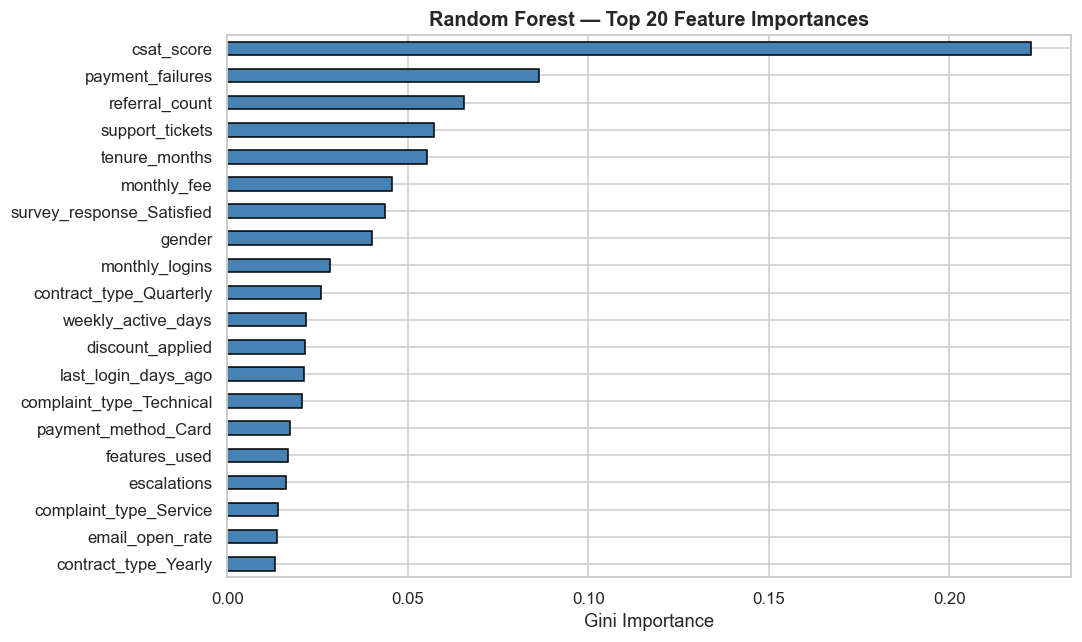


Top 10 features:
csat_score                   0.222690
payment_failures             0.086385
referral_count               0.065667
support_tickets              0.057332
tenure_months                0.055173
monthly_fee                  0.045466
survey_response_Satisfied    0.043755
gender                       0.039973
monthly_logins               0.028397
contract_type_Quarterly      0.025972


In [76]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_feats = feat_imp.head(20)

plt.figure(figsize=(10, 6))
top_feats.plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.xlabel('Gini Importance')
plt.title('Random Forest — Top 20 Feature Importances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feat_imp.head(10).to_string())

---
## 10. Model Comparison

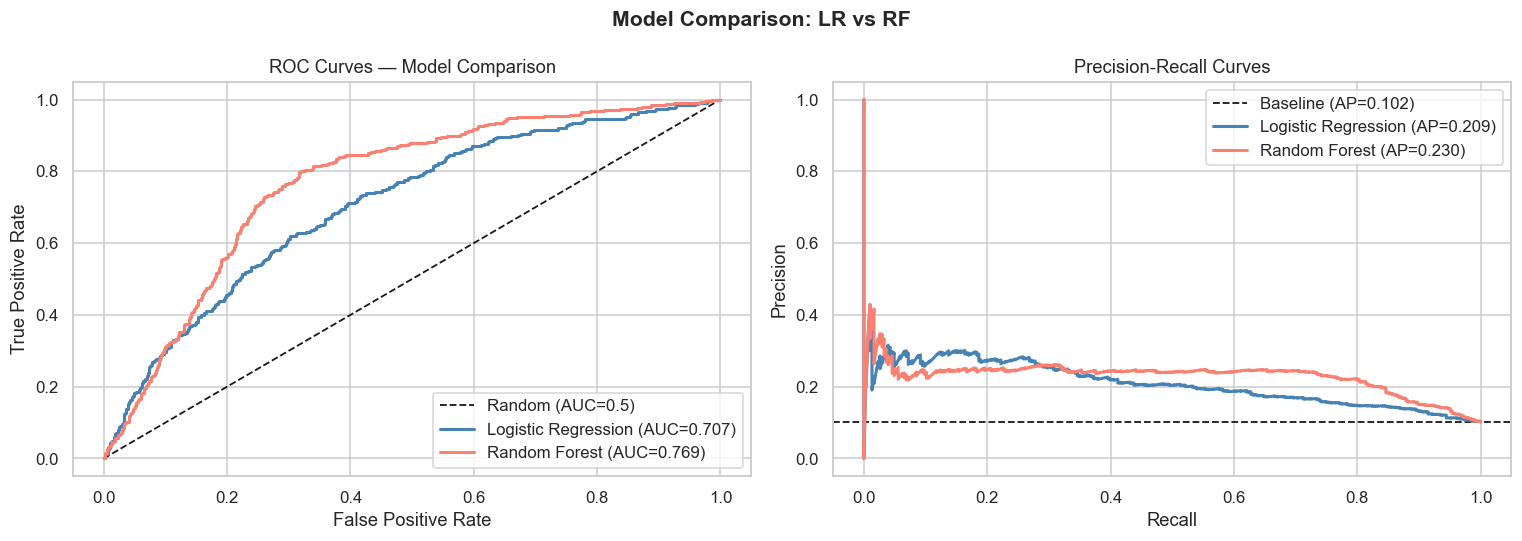

In [77]:
# ── 10.1  Add RF to ROC / PR curves ──
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 5))

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random (AUC=0.5)')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves — Model Comparison', fontsize=12)

ax_pr.axhline(y_test.mean(), color='k', linestyle='--', lw=1.2,
              label=f'Baseline (AP={y_test.mean():.3f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curves', fontsize=12)

auc_lr, ap_lr = plot_roc_pr(y_test, y_prob_lr, 'Logistic Regression', 'steelblue', ax_roc, ax_pr)
auc_rf, ap_rf = plot_roc_pr(y_test, y_prob_rf, 'Random Forest',       'salmon',    ax_roc, ax_pr)

ax_roc.legend()
ax_pr.legend()
plt.suptitle('Model Comparison: LR vs RF', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== Logistic Regression (threshold=0.58) ===
  Metric          Value
  ──────────────────────
  Accuracy       0.7490
  Precision      0.2063  (of flagged churners, how many are real)
  Recall         0.5131  (of real churners, how many we caught)
  F1             0.2943
  TN/FP/FN/TP  2090/604/149/157

=== Random Forest (threshold=0.30) ===
  Metric          Value
  ──────────────────────
  Accuracy       0.7413
  Precision      0.2412  (of flagged churners, how many are real)
  Recall         0.7157  (of real churners, how many we caught)
  F1             0.3608
  TN/FP/FN/TP  2005/689/87/219


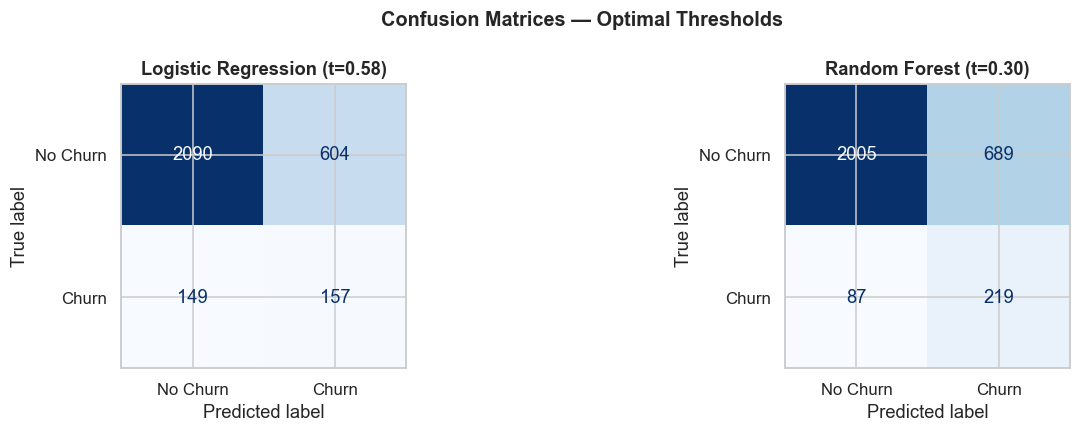

In [78]:
# ── 10.2  Confusion Matrix Side-by-Side ──
# Apply optimal threshold to RF as well
rf_f1_scores = [f1_score(y_test, (y_prob_rf >= t).astype(int), zero_division=0)
                for t in thresholds_range]
best_thresh_rf = thresholds_range[np.argmax(rf_f1_scores)]
y_pred_rf_opt  = (y_prob_rf >= best_thresh_rf).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

print(f"=== Logistic Regression (threshold={best_thresh_f1:.2f}) ===")
plot_confusion_matrix(y_test, y_pred_lr_opt, f'Logistic Regression (t={best_thresh_f1:.2f})', ax=axes[0])

print(f"\n=== Random Forest (threshold={best_thresh_rf:.2f}) ===")
plot_confusion_matrix(y_test, y_pred_rf_opt, f'Random Forest (t={best_thresh_rf:.2f})', ax=axes[1])

plt.suptitle('Confusion Matrices — Optimal Thresholds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


MODEL COMPARISON SCORECARD
                     Accuracy  Precision  Recall      F1  ROC-AUC  Avg Precision
Model                                                                           
LR — Default (0.5)     0.6803     0.1851  0.6275  0.2859   0.7074         0.2087
LR — Optimal (0.58)    0.7490     0.2063  0.5131  0.2943   0.7074         0.2087
RF — Default (0.5)     0.8720     0.2292  0.1078  0.1467   0.7687         0.2304
RF — Optimal (0.30)    0.7413     0.2412  0.7157  0.3608   0.7687         0.2304


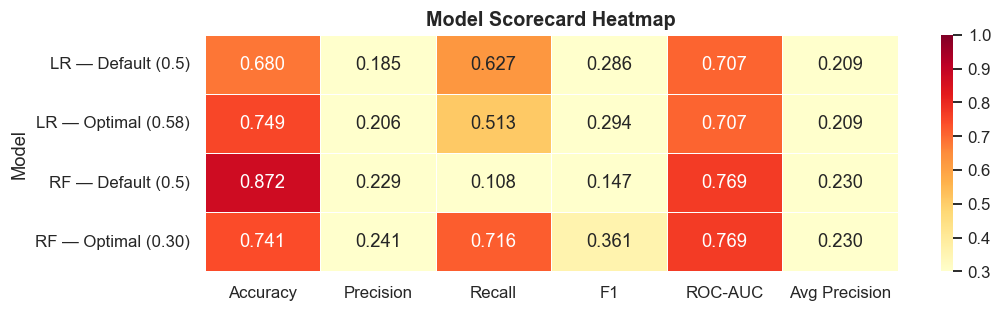

In [79]:
# ── 10.3  Summary Scorecard ──
def get_metrics(y_true, y_pred, y_prob, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'Avg Precision': average_precision_score(y_true, y_prob)
    }

scorecard = pd.DataFrame([
    get_metrics(y_test, y_pred_lr,     y_prob_lr, 'LR — Default (0.5)'),
    get_metrics(y_test, y_pred_lr_opt, y_prob_lr, f'LR — Optimal ({best_thresh_f1:.2f})'),
    get_metrics(y_test, y_pred_rf,     y_prob_rf, 'RF — Default (0.5)'),
    get_metrics(y_test, y_pred_rf_opt, y_prob_rf, f'RF — Optimal ({best_thresh_rf:.2f})'),
])
scorecard = scorecard.set_index('Model')
scorecard = scorecard.round(4)

print("\n" + "=" * 70)
print("MODEL COMPARISON SCORECARD")
print("=" * 70)
print(scorecard.to_string())

# Heatmap for visual comparison
plt.figure(figsize=(10, 3))
sns.heatmap(scorecard.astype(float), annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, vmin=0.3, vmax=1.0)
plt.title('Model Scorecard Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Business Value & Decision Framework

### Cost-Benefit Analysis of Churn Interventions

In [80]:
# ── Business Cost Simulation ──
# Adjust these values based on your real business context
CLV = 500          # Customer Lifetime Value (revenue saved by retaining a churner)
INTERVENTION_COST = 30   # Cost of contacting / offering discount to flagged customer

def business_value(y_true, y_pred, clv=CLV, cost=INTERVENTION_COST):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    revenue_saved  = tp * clv          # correctly intervened churners
    wasted_cost    = fp * cost         # interventions on loyal customers
    missed_revenue = fn * clv          # churners we missed
    net_value      = revenue_saved - wasted_cost
    print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    print(f"  Revenue saved:   ${revenue_saved:>10,.0f}")
    print(f"  Wasted cost:    -${wasted_cost:>10,.0f}")
    print(f"  Missed revenue: -${missed_revenue:>10,.0f}  (opportunity cost)")
    print(f"  Net Value:       ${net_value:>10,.0f}")
    return net_value

print(f"Parameters: CLV=${CLV}, Intervention Cost=${INTERVENTION_COST}\n")
print(f"[CLV=${CLV}, Cost=${INTERVENTION_COST}]")
print("─" * 50)
print(f"\n→ Logistic Regression (optimal threshold {best_thresh_f1:.2f}):")
net_lr = business_value(y_test, y_pred_lr_opt)
print(f"\n→ Random Forest (optimal threshold {best_thresh_rf:.2f}):")
net_rf = business_value(y_test, y_pred_rf_opt)
print(f"\nBusiness Net Value Comparison:")
print(f"  LR: ${net_lr:,.0f}  |  RF: ${net_rf:,.0f}")
print(f"  Winner: {'LR' if net_lr > net_rf else 'RF'} by ${abs(net_lr - net_rf):,.0f}")

Parameters: CLV=$500, Intervention Cost=$30

[CLV=$500, Cost=$30]
──────────────────────────────────────────────────

→ Logistic Regression (optimal threshold 0.58):
  TP=157, FP=604, FN=149, TN=2090
  Revenue saved:   $    78,500
  Wasted cost:    -$    18,120
  Missed revenue: -$    74,500  (opportunity cost)
  Net Value:       $    60,380

→ Random Forest (optimal threshold 0.30):
  TP=219, FP=689, FN=87, TN=2005
  Revenue saved:   $   109,500
  Wasted cost:    -$    20,670
  Missed revenue: -$    43,500  (opportunity cost)
  Net Value:       $    88,830

Business Net Value Comparison:
  LR: $60,380  |  RF: $88,830
  Winner: RF by $28,450


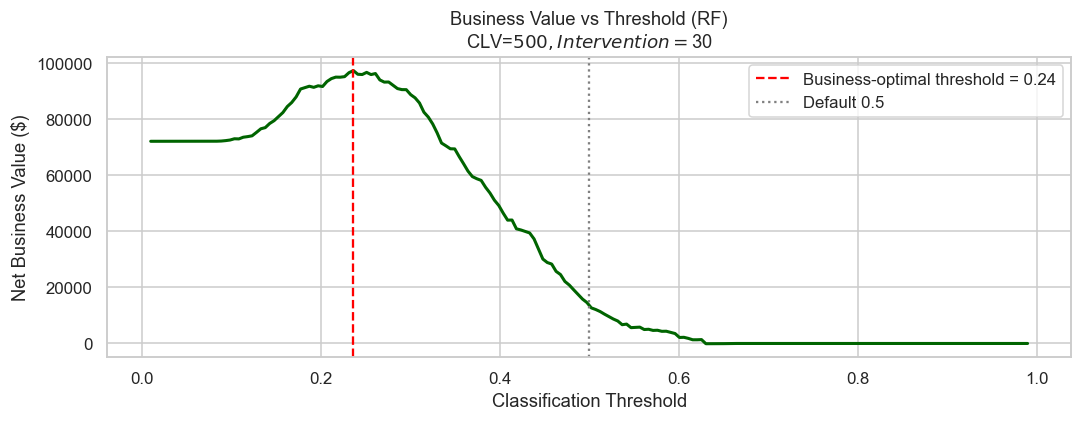


Business-optimal threshold for RF: 0.24
Max net value: $97,410


In [81]:
# Scan across thresholds to find the business-optimal cutoff for RF
net_values = []
for t in thresholds_range:
    pred = (y_prob_rf >= t).astype(int)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp_ = cm.ravel()
    nv = tp_ * CLV - fp * INTERVENTION_COST
    net_values.append(nv)

best_biz_thresh = thresholds_range[np.argmax(net_values)]

plt.figure(figsize=(10, 4))
plt.plot(thresholds_range, net_values, color='darkgreen', lw=2)
plt.axvline(best_biz_thresh, color='red', linestyle='--',
            label=f'Business-optimal threshold = {best_biz_thresh:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Default 0.5')
plt.xlabel('Classification Threshold')
plt.ylabel('Net Business Value ($)')
plt.title(f'Business Value vs Threshold (RF)\nCLV=${CLV}, Intervention=${INTERVENTION_COST}', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBusiness-optimal threshold for RF: {best_biz_thresh:.2f}")
print(f"Max net value: ${max(net_values):,.0f}")

---
## 12. Cross-Validation — Checking for Overfitting

In [82]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Note: we use X_train_sc (scaled, no SMOTE) for unbiased CV
# Applying SMOTE inside each fold is the proper approach but out of scope here
lr_cv_scores = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_cv_scores = cross_val_score(rf, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print("5-Fold Stratified Cross-Validation (ROC-AUC):")
print(f"  Logistic Regression: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"                       Folds: {np.round(lr_cv_scores, 4)}")
print(f"  Random Forest:       {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")
print(f"                       Folds: {np.round(rf_cv_scores, 4)}")

# Compare CV score vs test score to detect overfitting
print(f"\nTest AUC: LR={auc_lr:.4f}  RF={auc_rf:.4f}")
print(f"CV AUC:  LR={lr_cv_scores.mean():.4f}  RF={rf_cv_scores.mean():.4f}")
lr_overfit = lr_cv_scores.mean() - auc_lr
rf_overfit = rf_cv_scores.mean() - auc_rf
print(f"\nCV-Test gap (large positive = overfitting):")
print(f"  LR gap: {lr_overfit:.4f}   RF gap: {rf_overfit:.4f}")

5-Fold Stratified Cross-Validation (ROC-AUC):
  Logistic Regression: 0.7203 ± 0.0089
                       Folds: [0.7358 0.7169 0.7094 0.7164 0.7228]
  Random Forest:       0.7971 ± 0.0135
                       Folds: [0.7841 0.7926 0.8228 0.7969 0.7892]

Test AUC: LR=0.7074  RF=0.7687
CV AUC:  LR=0.7203  RF=0.7971

CV-Test gap (large positive = overfitting):
  LR gap: 0.0128   RF gap: 0.0284


---
## 13. Summary & Key Takeaways

### Logistic Regression vs. Random Forest for Churn

| Dimension | Logistic Regression | Random Forest |
|---|---|---|
| **Interpretability** | High — coefficients = log-odds | Medium — feature importances only |
| **Assumptions** | Linear log-odds boundary | None (non-parametric) |
| **Predictive power** | Good baseline | Usually better, especially non-linear |
| **Handling imbalance** | `class_weight='balanced'` | `class_weight='balanced'` |
| **Feature scaling** | Required | Not required |
| **Interpretable output** | Probability is well-calibrated | May need Platt scaling |
| **When to use** | Regulated industries, quick baseline, explainability required | Better accuracy needed, complex interactions |

---

### Interview Cheat Sheet

**Q: Why not use accuracy for imbalanced classification?**  
A: A model predicting all 0s achieves high accuracy but zero recall on the minority class — it is useless for churn detection. Use F1, ROC-AUC, or PR-AUC instead.

**Q: What is the difference between ROC-AUC and PR-AUC?**  
A: ROC-AUC includes TN in FPR which flatters models on imbalanced data. PR-AUC focuses only on TP, FP, FN — more informative when positives are rare.

**Q: How do you choose the classification threshold?**  
A: It depends on the cost asymmetry. Options: Youden's J (balance TPR/FPR), F1-maximising threshold, or a business cost-benefit simulation.

**Q: What is SMOTE and when should you use it?**  
A: Synthetic Minority Over-sampling TEchnique generates new minority-class samples by interpolating between real neighbors. Apply only on training data to avoid data leakage. Use when the minority class has enough samples to interpolate meaningfully (≥50–100).

**Q: What does an Odds Ratio of 2.5 mean?**  
A: A one-unit increase in that feature multiplies the odds of churn by 2.5 — i.e., 150% higher odds.

**Q: Logistic Regression coefficient is 0.4. What does that mean?**  
A: The log-odds of churn increase by 0.4 per unit increase. The odds ratio is exp(0.4) ≈ 1.49 — odds of churn increase by 49%.

**Q: What is Precision-Recall trade-off?**  
A: Lowering the threshold catches more churners (↑ Recall) but also flags more non-churners (↓ Precision). The optimal point depends on whether FN or FP is more costly.

---

### Business Recommendations

1. **Segment by predicted probability**, not just binary class. Customers with 70–90% churn probability warrant a premium retention offer; 30–50% may need a gentle nudge only.
2. **Re-train monthly** — customer behavior drifts, especially after product changes or competitive actions.
3. **Track business KPIs**, not model metrics, in production: retention rate, ROI of interventions.
4. **Use Logistic Regression** when executives need to understand *why* a customer was flagged. Use Random Forest when prediction accuracy is the primary goal.
5. **Monitor class distribution** in production data — if the churn rate shifts significantly, recalibrate or retrain.